# A notebook to plot all data files created during a UM Regional Nesting Suite (RNS) run - rAM3

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import iris
import os
import warnings

In [48]:
ROSE_SUITE_ID = 'rCM3-test-UM-fcst'
NOTEBOOK_PATH = ('/home/548/pag548/code/UM_config_tools/notebooks')

In [4]:
home_dir=os.environ['HOME']
HOME=Path(home_dir)

In [5]:
CYCLE = '20220226T0000Z'
WORKDIR = HOME / 'cylc-run' / ROSE_SUITE_ID / 'work'
SHAREDIR = HOME / 'cylc-run' / ROSE_SUITE_ID / 'share'
warnings.filterwarnings('ignore',module='iris') 

In [6]:
# First rAM3 task is to run is ec_um_recon. This loads the grib file
#/scratch/<PROJECT>/<USER?/EC_GRIB_PARALLEL/ec_grib_202202260000.t+000 and reconfigures it 
# for our domain (in this case 100 x 100) by using our Land/Sea Mask ancillary

EC_UM_DIR = SHAREDIR / 'cycle' / CYCLE / 'ec/um'
ec_recon = iris.load(EC_UM_DIR / 'ec_cb000')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [7]:
# This file contains 116 variables!
output = {}
long_names = []
std_names = []
var_names = []
for cube in ec_recon:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [10]:
output

{STASH(model=1, section=0, item=14): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=15): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=16): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=21): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=34): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=35): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=36): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=37): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=207): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=213): {'var_name ': None,
  'st

In [9]:
ec_recon

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i229 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i230 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i233 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i234 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i236 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i237 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i240 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i246 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i376 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i390 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i397 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i398 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i490 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i491 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i492 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i493 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i005 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i006 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i017 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i018 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i022 / (unknown) (latitude: 100; longitude: 100)>,
<iris 'Cube' of Convective cloud amount with anvil / (1) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i212 / (unknown) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of m01s00i253 / (unknown) (model_level_number: 70; latitude: 100; longitude: 100)>,
<iris 'Cube' of cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of liquid_cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of ice_cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of mass_concentration_of_biogenic_nmvoc_in_air / (kg/kg) (model_level_number: 71; latitude: 100; longitude: 100)>,
<iris 'Cube' of mass_fraction_of_fresh_biomass_burning_dry_aerosol_in_air / (kg/kg) (

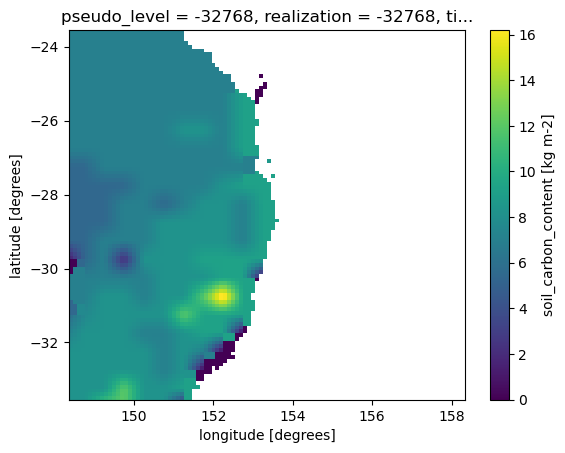

In [13]:
xr.DataArray.from_iris(ec_recon[95]).plot()

In [17]:
# nci_hres_eccb then replaces the land surface fields at 0.1 resolution (or 0.11 resolution) of these files (ec_cb0*)
# depending on the source - ERA5/BARRA. The impacts of these updates can't be seen on our grids.
# The next task is nci_hres_ic this produces an ASTART file.

In [28]:
# Anyway - the next tasks to run are the UM_recon task. This creates the ASTART flile
GAL9_DIR = SHAREDIR / 'cycle' / CYCLE / 'Test_Ocean/test/GAL9'
ASTART_FILE = GAL9_DIR / 'ics/GAL9_astart'
astart_cube = iris.load(ASTART_FILE)

In [26]:
# This file contains 164 variables on our 50x50 forecast grid
output = {}
long_names = []
std_names = []
var_names = []
for cube in astart_cube:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [27]:
output

{STASH(model=1, section=0, item=14): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=15): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=16): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=21): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=34): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=35): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=36): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=37): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=96): {'var_name ': None,
  'standard_name': None,
  'long name': None},
 STASH(model=1, section=0, item=207): {'var_name ': None,
  'sta

In [25]:
astart_cube

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i096 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i221 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i229 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i230 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i233 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i234 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i236 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i237 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i240 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i241 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i242 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i274 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i275 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i276 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i277 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i278 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i279 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i280 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i281 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i282 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i283 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i284 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i285 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i376 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i377 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i380 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i381 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i382 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i383 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i384 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i385 / (unknown) (pseudo_level: 27; latitude: 

In [30]:
# Now the ASTART file exists, we can run rci_hres_ic. This updates the ASTART file with two new variables. 
output = {}
long_names = []
std_names = []
var_names = []
for cube in astart_cube:
        #print (f'{file.name} {cube.long_name} {cube.standard_name} {cube.var_name}')
        long_names.append(cube.long_name)
        var_names.append(cube.var_name)
        std_names.append(cube.standard_name)
        output[cube.attributes['STASH']] = { 'var_name ' : cube.var_name, 'standard_name' : cube. standard_name, 'long name' : cube.long_name }

In [32]:
# Now we can build the LBCs for the first few hours of our forecast.
LBC_FILE = GAL9_DIR / 'lbcs/GAL9_alabc_000'
LBC = iris.load(LBC_FILE)

TypeError: unsupported format string passed to SplittableInt.__format__

In [33]:
LBC_FILE

PosixPath('/home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/Test_Ocean/test/GAL9/lbcs/GAL9_alabc_000')

In [34]:
import mule

In [39]:
ff = mule.FieldsFile.from_file(str(LBC_FILE))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/mule/stashmaster.py:259: UserWarning: 
Unable to load STASHmaster from version string, path does not exist
Path: $UMDIR/vn13.5/ctldata/STASHmaster/STASHmaster_A
Please check that the value of mule.stashmaster.STASHMASTER_PATH_PATTERN is correct for your site/configuration
  warnings.warn(msg)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/mule/validators.py:198: UserWarning: 
File: /home/548/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/20220226T0000Z/Test_Ocean/test/GAL9/lbcs/GAL9_alabc_000
Incorrect dataset_type (found 5, should be one of (3,))
  warnings.warn(msg)


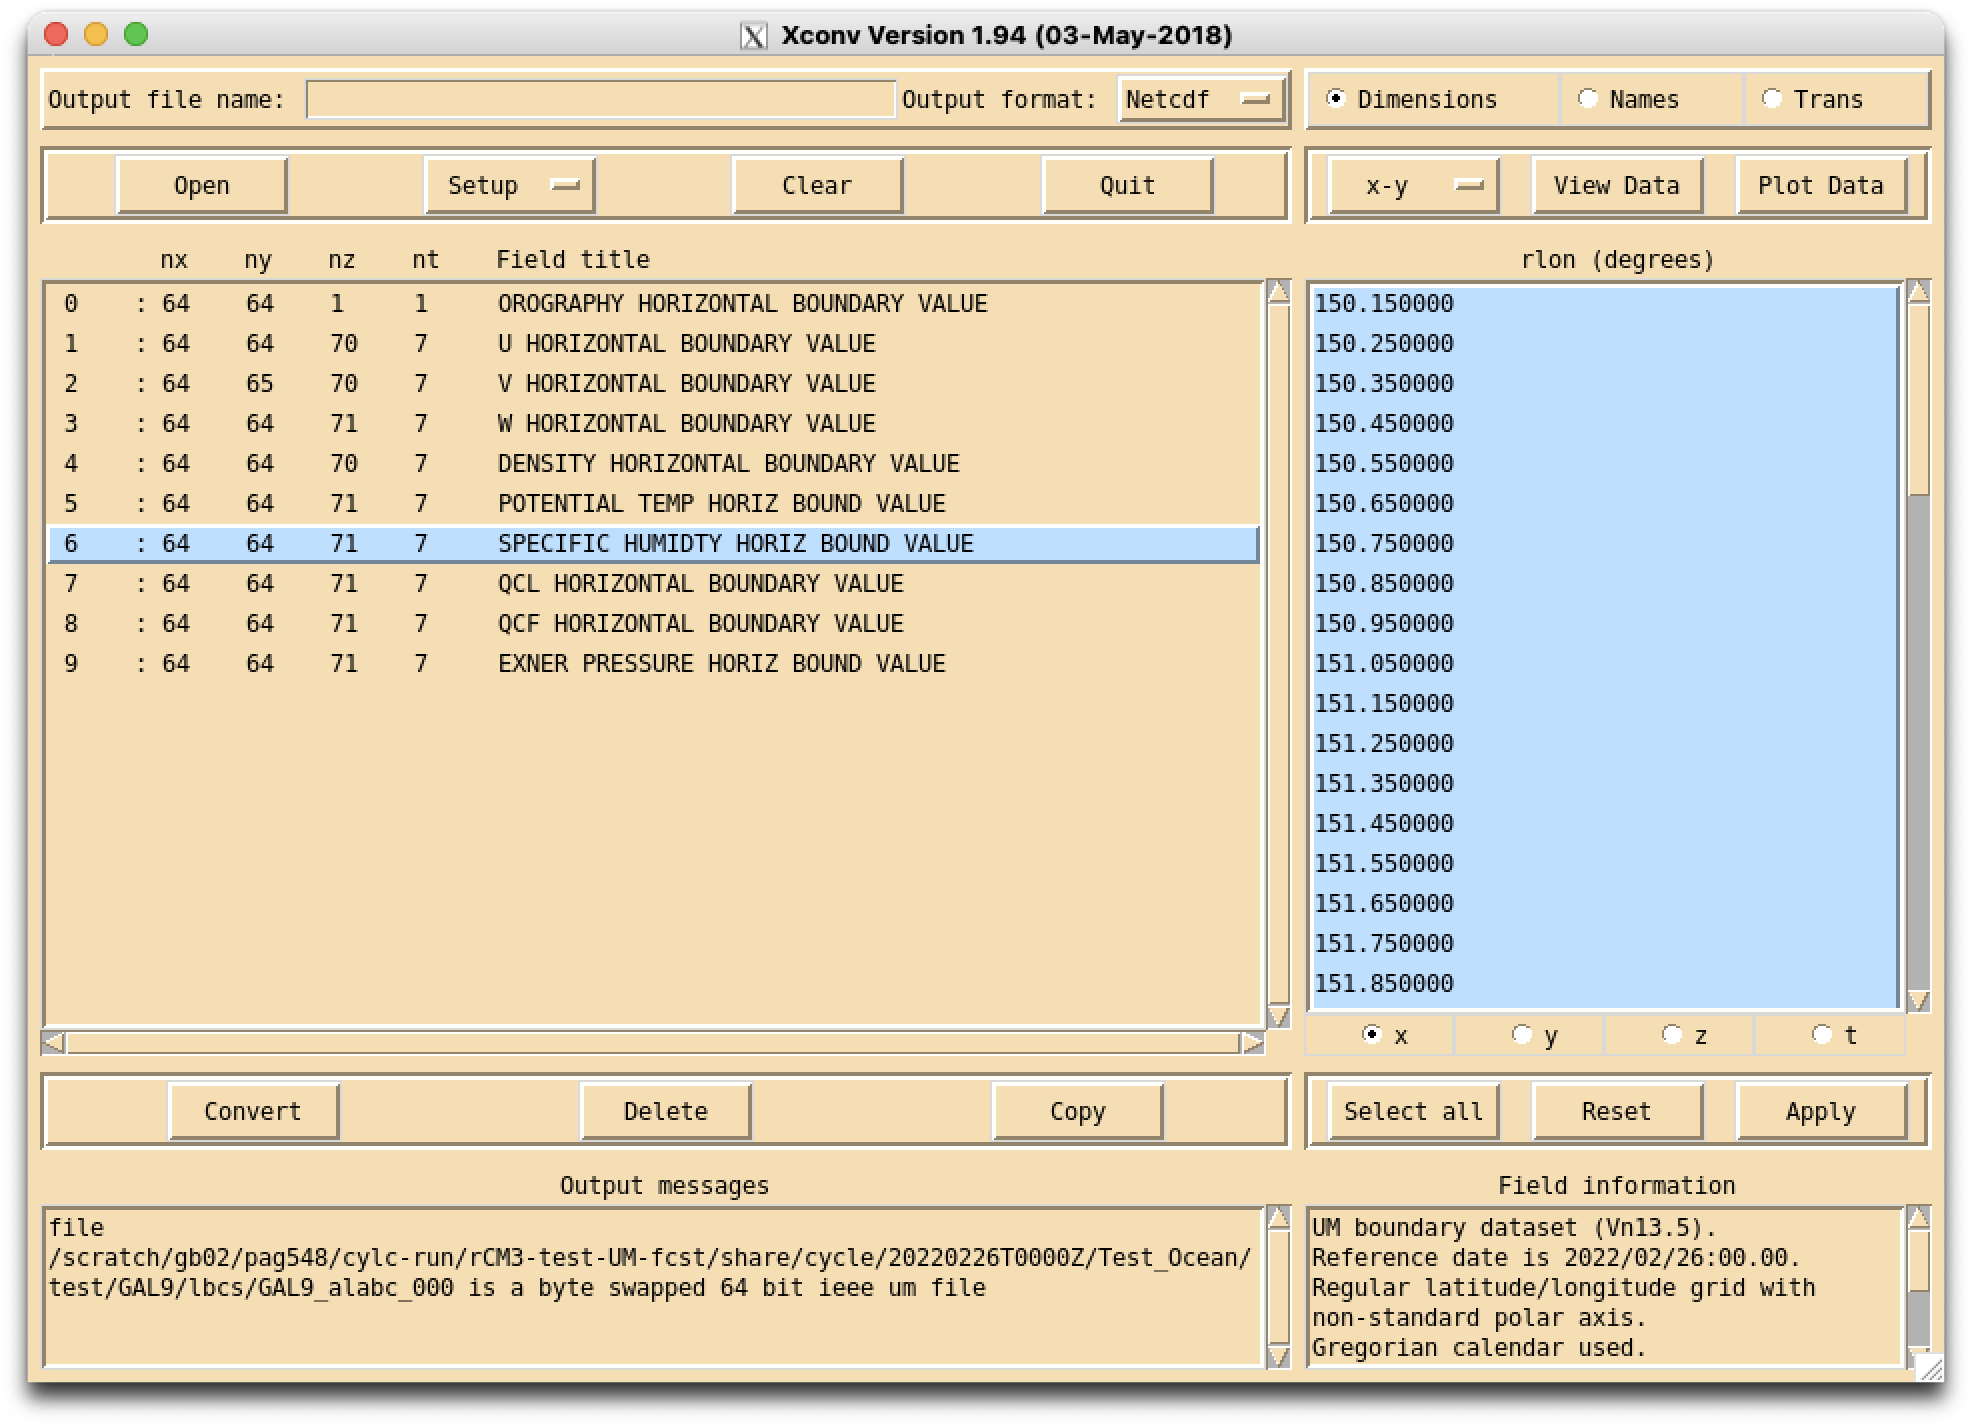

In [52]:
# Ok let's just plot the ouputs from xconv
from IPython.display import Image, display
display(Image(filename=str(NOTEBOOK_PATH)+ '/images/LBC_fields.png'))

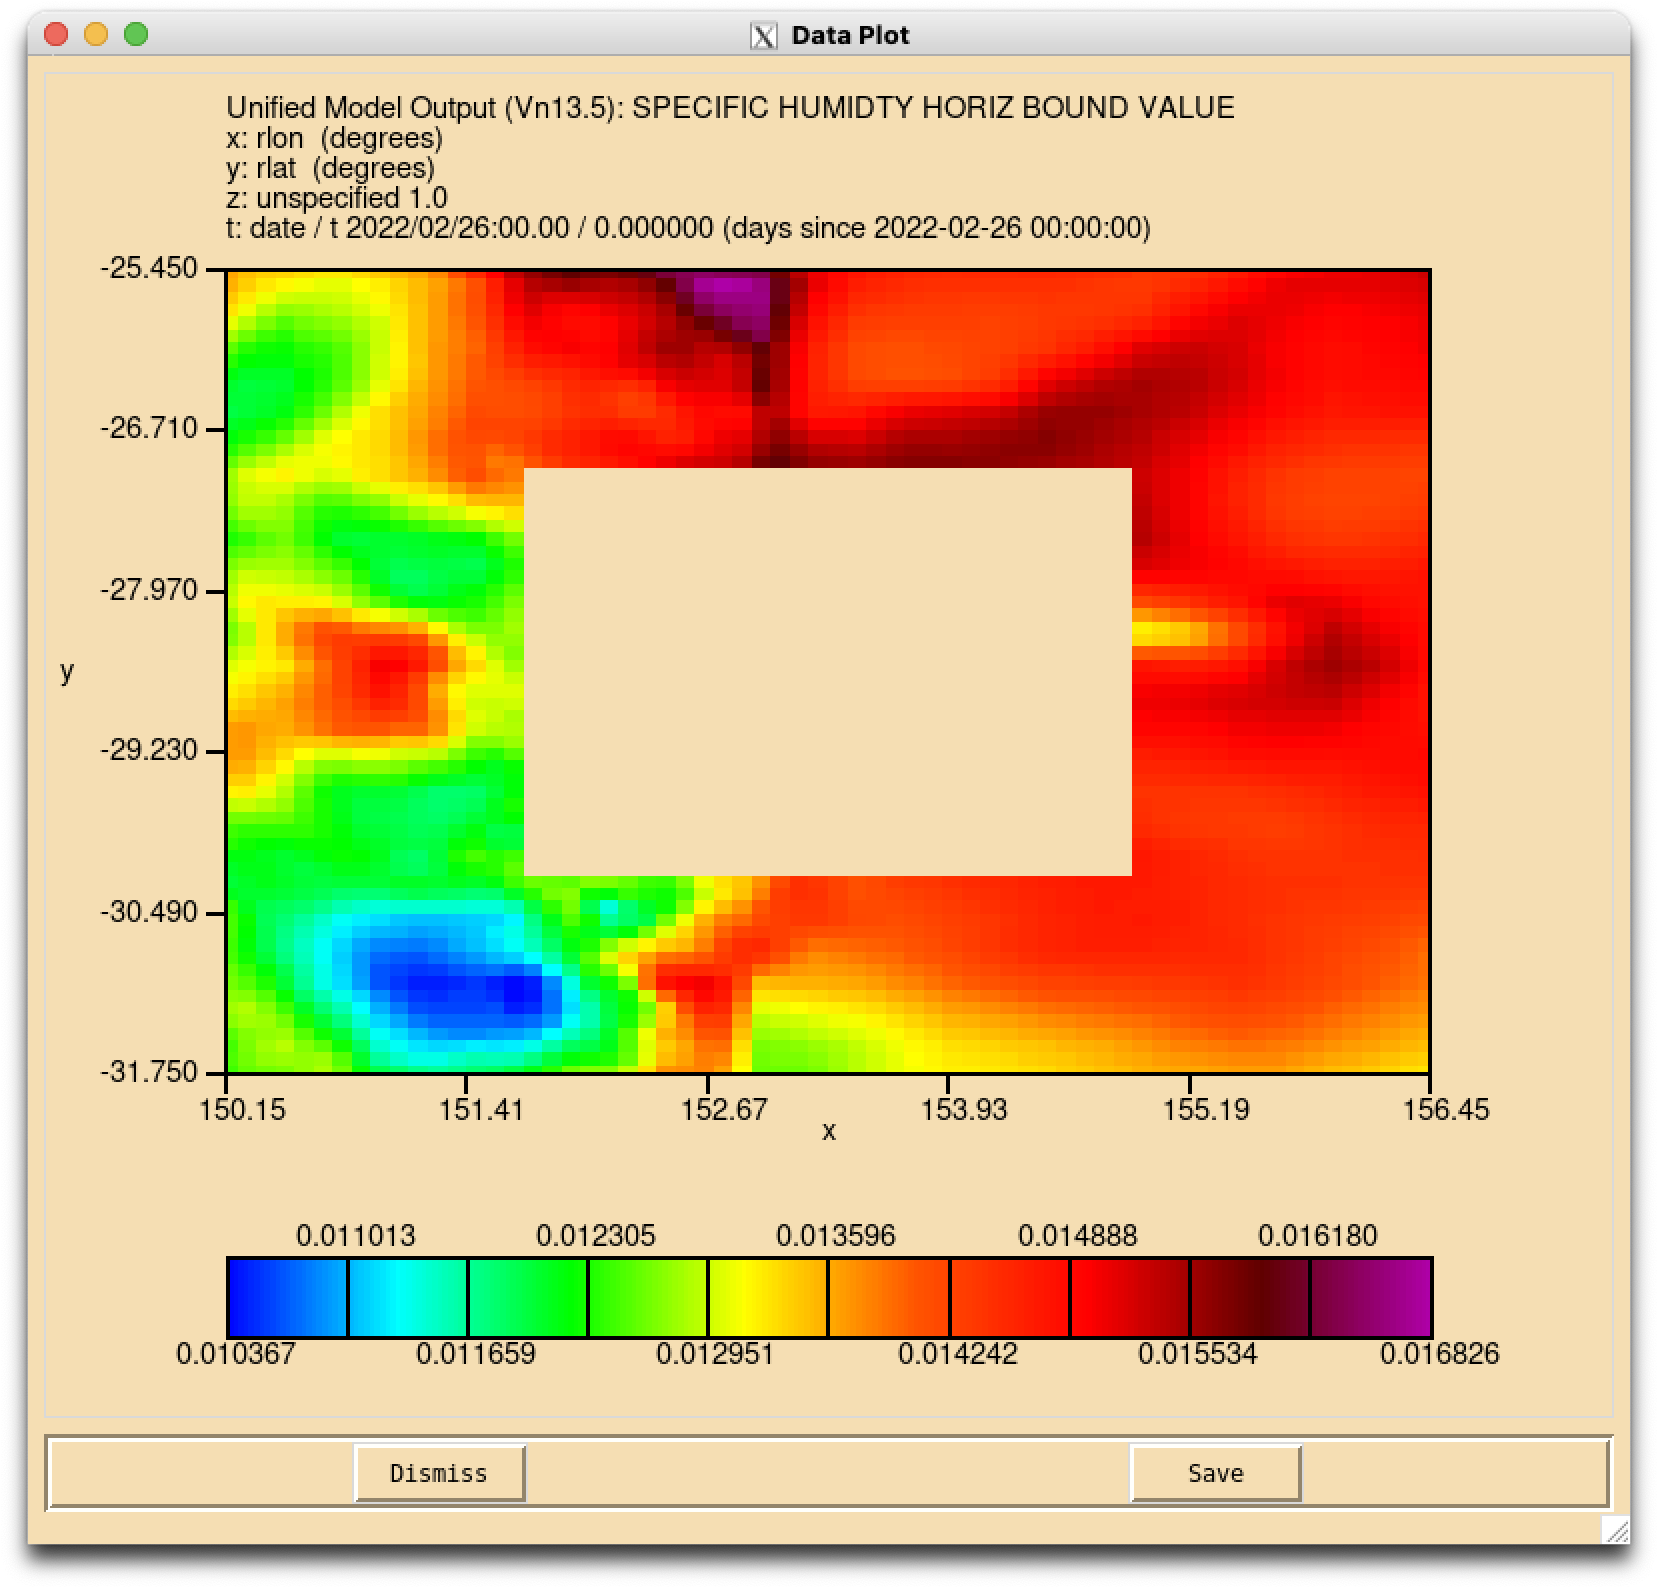

In [53]:
display(Image(filename=str(NOTEBOOK_PATH)+ '/images/LBC_plot.png'))

In [55]:
# Now we can run a forecast task. This produces an extra initial condition file
UM_NSAA_DA_FILE = GAL9_DIR / 'ics/umnsaa_da006'
UM_NSAA_DA = iris.load(UM_NSAA_DA_FILE)

In [56]:
UM_NSAA_DA

[<iris 'Cube' of m01s00i014 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i015 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i016 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i021 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i034 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i035 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i036 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i037 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i096 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i207 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i213 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i216 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i221 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i225 / (unknown) (pseudo_level: 5; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i229 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i230 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i233 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i234 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i236 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i237 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i238 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i239 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i240 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i241 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i242 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i259 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i260 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i261 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i262 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i263 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i264 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i274 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i275 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i276 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i277 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i278 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i279 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i280 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i281 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i282 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i283 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i284 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i285 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i348 / (unknown) (latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i376 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i377 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i380 / (unknown) (pseudo_level: 9; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i381 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i382 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i383 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i384 / (unknown) (pseudo_level: 27; latitude: 50; longitude: 50)>,
<iris 'Cube' of m01s00i385 / (unknown) (pseudo_level: 27; latitude: 

In [62]:
UM_NSAA_PA_FILE = GAL9_DIR / 'um/umnsaa_pa000'
UM_NSAA_PA = iris.load(UM_NSAA_PA_FILE)

In [63]:
UM_NSAA_PA

[<iris 'Cube' of land_binary_mask / (1) (latitude: 50; longitude: 50)>,
<iris 'Cube' of surface_altitude / (m) (latitude: 50; longitude: 50)>]

In [64]:
UM_NSAA_PB_FILE = GAL9_DIR / 'um/umnsaa_pb000'
UM_NSAA_PB = iris.load(UM_NSAA_PB_FILE)

In [65]:
UM_NSAA_PB

[<iris 'Cube' of air_pressure_at_sea_level / (Pa) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of convective_rainfall_amount / (kg m-2) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of stratiform_rainfall_amount / (kg m-2) (time: 180; latitude: 50; longitude: 50)>,
<iris 'Cube' of wind_speed_of_gust / (m s-1) (time: 180; latitude: 50; longitude: 50)>]

In [66]:
UM_NSAA_CB_FILE = GAL9_DIR / 'um/umnsaa_cb000'
UM_NSAA_CB = iris.load(UM_NSAA_CB_FILE)

In [67]:
UM_NSAA_CB

M01S00I253 (unknown),model_level_number,time,latitude,longitude
Shape,70,2,50,50
Dimension coordinates,,,,
model_level_number,x,-,-,-
time,-,x,-,-
latitude,-,-,x,-
longitude,-,-,-,x
Auxiliary coordinates,,,,
level_height,x,-,-,-
sigma,x,-,-,-
forecast_period,-,x,-,-


etc.